# 最小生成树（MST）：Prim 与 Kruskal 算法

## 题目

给定以下6个顶点的无向带权图：

| 顶点 | A、B、C、D、E、F |
|------|------------------|

| 边 | 权值 |
|----|------|
| A-B | 2 |
| A-D | 3 |
| B-C | 4 |
| B-E | 1 |
| C-F | 5 |
| D-E | 6 |
| E-F | 2 |

图结构：

```
    A ----2---- B ----4---- C
    |           |           |
    3           1           5
    |           |           |
    D ----6---- E ----2---- F
```

要求：用 **Prim 算法** 和 **Kruskal 算法** 分别求出最小生成树（MST）。

## 1. 图的定义

In [1]:
# 顶点
vertices = ['A', 'B', 'C', 'D', 'E', 'F']

# 边 (u, v, weight)
edges = [
    ('A', 'B', 2),
    ('A', 'D', 3),
    ('B', 'C', 4),
    ('B', 'E', 1),
    ('C', 'F', 5),
    ('D', 'E', 6),
    ('E', 'F', 2),
]

# 构建邻接表
graph = {v: [] for v in vertices}
for u, v, w in edges:
    graph[u].append((v, w))
    graph[v].append((u, w))

print("邻接表:")
for v in vertices:
    print(f"  {v}: {graph[v]}")

邻接表:
  A: [('B', 2), ('D', 3)]
  B: [('A', 2), ('C', 4), ('E', 1)]
  C: [('B', 4), ('F', 5)]
  D: [('A', 3), ('E', 6)]
  E: [('B', 1), ('D', 6), ('F', 2)]
  F: [('C', 5), ('E', 2)]


## 2. Prim 算法

### 算法思想
从任意起点出发，每次选择当前已访问顶点集合与未访问顶点集合之间**权值最小的边**，将对应顶点加入已访问集合，直到所有顶点都被访问。

### 时间复杂度
- 使用优先队列（堆）实现：**O(E log V)**
- 使用邻接矩阵暴力实现：O(V²)

### 从 A 开始执行 Prim

In [2]:
import heapq

def prim(graph, start):
    """
    Prim 算法求 MST
    
    参数:
        graph: 邻接表 {vertex: [(neighbor, weight), ...]}
        start: 起始顶点
    返回:
        mst_edges: MST 中的边列表
        total_weight: 总权值
    """
    visited = set()
    mst_edges = []
    total_weight = 0
    
    # 优先队列: (weight, from_vertex, to_vertex)
    pq = [(0, None, start)]
    
    print(f"{'步骤':<6} {'选中边':<14} {'权值':<6} {'visited'}")
    print("-" * 50)
    step = 0
    
    while pq and len(visited) < len(graph):
        weight, from_v, to_v = heapq.heappop(pq)
        
        if to_v in visited:
            continue
        
        visited.add(to_v)
        
        if from_v is not None:
            step += 1
            mst_edges.append((from_v, to_v, weight))
            total_weight += weight
            print(f"  {step:<4} {from_v + '-' + to_v:<14} {weight:<6} {sorted(visited)}")
        else:
            print(f"  起始  {'-':<14} {'-':<6} {sorted(visited)}")
        
        for neighbor, w in graph[to_v]:
            if neighbor not in visited:
                heapq.heappush(pq, (w, to_v, neighbor))
    
    return mst_edges, total_weight


prim_mst, prim_total = prim(graph, 'A')
print("-" * 50)
print(f"\nPrim MST 边集: {prim_mst}")
print(f"Prim MST 总权值: {prim_total}")

步骤     选中边            权值     visited
--------------------------------------------------
  起始  -              -      ['A']
  1    A-B            2      ['A', 'B']
  2    B-E            1      ['A', 'B', 'E']
  3    E-F            2      ['A', 'B', 'E', 'F']
  4    A-D            3      ['A', 'B', 'D', 'E', 'F']
  5    B-C            4      ['A', 'B', 'C', 'D', 'E', 'F']
--------------------------------------------------

Prim MST 边集: [('A', 'B', 2), ('B', 'E', 1), ('E', 'F', 2), ('A', 'D', 3), ('B', 'C', 4)]
Prim MST 总权值: 12


## 3. Kruskal 算法

### 算法思想
将所有边按权值从小到大排序，依次检查每条边：若该边的两个端点不在同一个连通分量中（用并查集判断），则将该边加入 MST，并合并两个连通分量。

### 时间复杂度
- 排序：O(E log E)
- 并查集操作：O(E α(V)) ≈ O(E)
- 总体：**O(E log E)**

In [3]:
class UnionFind:
    """并查集（带路径压缩和按秩合并）"""
    def __init__(self, vertices):
        self.parent = {v: v for v in vertices}
        self.rank = {v: 0 for v in vertices}
    
    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])  # 路径压缩
        return self.parent[x]
    
    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False
        # 按秩合并
        if self.rank[rx] < self.rank[ry]:
            self.parent[rx] = ry
        elif self.rank[rx] > self.rank[ry]:
            self.parent[ry] = rx
        else:
            self.parent[ry] = rx
            self.rank[rx] += 1
        return True


def kruskal(vertices, edges):
    """
    Kruskal 算法求 MST
    
    参数:
        vertices: 顶点列表
        edges: 边列表 [(u, v, weight), ...]
    返回:
        mst_edges: MST 中的边列表
        total_weight: 总权值
    """
    uf = UnionFind(vertices)
    
    # 按权值从小到大排序
    sorted_edges = sorted(edges, key=lambda e: e[2])
    
    print("排序后的边:", [(f"{u}-{v}", w) for u, v, w in sorted_edges])
    print()
    print(f"{'步骤':<6} {'检查边':<14} {'权值':<6} {'操作'}")
    print("-" * 60)
    
    mst_edges = []
    total_weight = 0
    step = 0
    
    for u, v, w in sorted_edges:
        step += 1
        if uf.union(u, v):
            # 不在同一集合，加入 MST
            mst_edges.append((u, v, w))
            total_weight += w
            print(f"  {step:<4} {u + '-' + v:<14} {w:<6} 选中 → 加入MST")
        else:
            print(f"  {step:<4} {u + '-' + v:<14} {w:<6} 跳过 (会形成环)")
    
    print("-" * 60)
    return mst_edges, total_weight


kruskal_mst, kruskal_total = kruskal(vertices, edges)
print(f"\nKruskal MST 边集: {kruskal_mst}")
print(f"Kruskal MST 总权值: {kruskal_total}")

排序后的边: [('B-E', 1), ('A-B', 2), ('E-F', 2), ('A-D', 3), ('B-C', 4), ('C-F', 5), ('D-E', 6)]

步骤     检查边            权值     操作
------------------------------------------------------------
  1    B-E            1      选中 → 加入MST
  2    A-B            2      选中 → 加入MST
  3    E-F            2      选中 → 加入MST
  4    A-D            3      选中 → 加入MST
  5    B-C            4      选中 → 加入MST
  6    C-F            5      跳过 (会形成环)
  7    D-E            6      跳过 (会形成环)
------------------------------------------------------------

Kruskal MST 边集: [('B', 'E', 1), ('A', 'B', 2), ('E', 'F', 2), ('A', 'D', 3), ('B', 'C', 4)]
Kruskal MST 总权值: 12


## 4. 结果可视化

用 networkx + matplotlib 绘制原图和 MST。

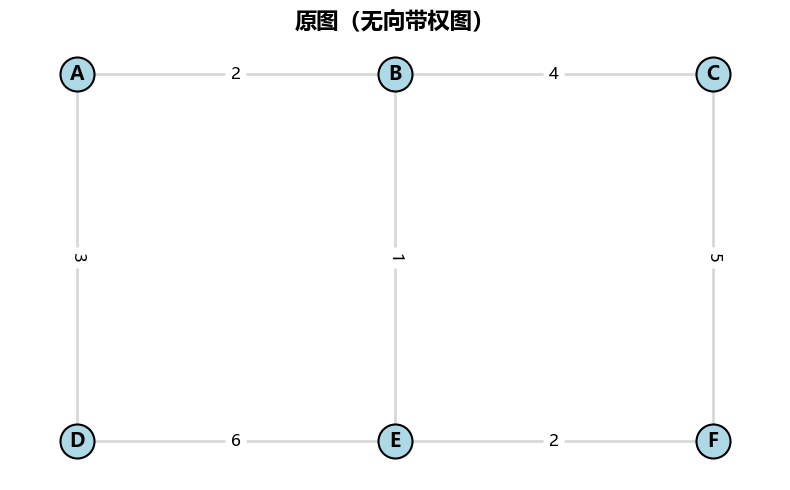

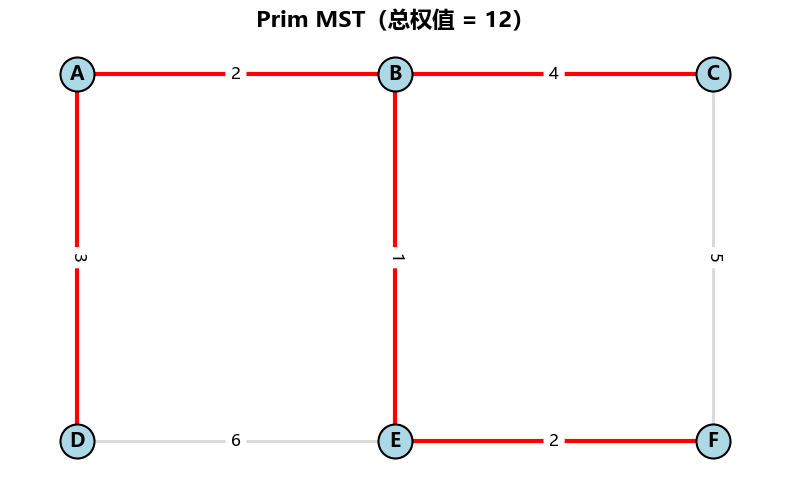

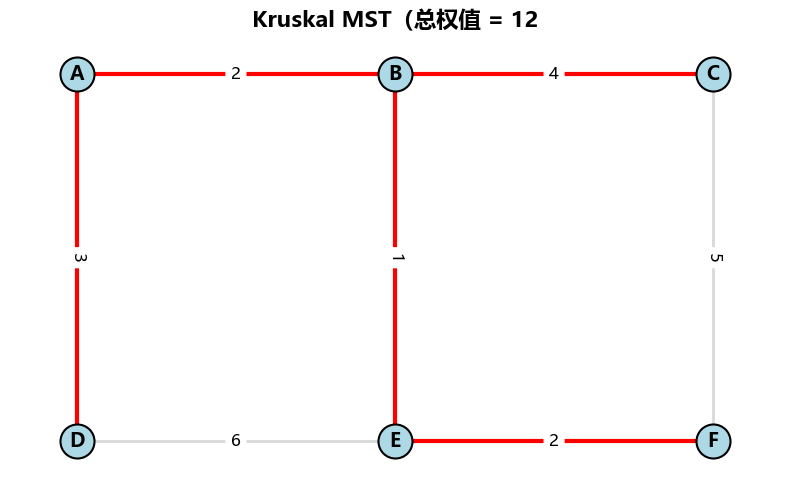

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

def draw_graph(edges, highlight_edges=None, title=""):
    """绘制图，highlight_edges 高亮 MST 边"""
    G = nx.Graph()
    G.add_weighted_edges_from(edges)
    
    # 固定布局 - 手动指定位置
    pos = {
        'A': (0, 1),
        'B': (1, 1),
        'C': (2, 1),
        'D': (0, 0),
        'E': (1, 0),
        'F': (2, 0),
    }
    
    plt.figure(figsize=(8, 5))
    
    # 绘制所有边（灰色）
    nx.draw_networkx_edges(G, pos, alpha=0.3, width=2, edge_color='gray')
    
    # 高亮 MST 边
    if highlight_edges:
        highlight_graph = nx.Graph()
        highlight_graph.add_weighted_edges_from(highlight_edges)
        nx.draw_networkx_edges(highlight_graph, pos, width=3, edge_color='red')
    
    # 绘制顶点
    nx.draw_networkx_nodes(G, pos, node_size=600, node_color='lightblue',
                           edgecolors='black', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')
    
    # 绘制边权值标签
    edge_labels = {(u, v): w for u, v, w in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# 绘制原图
draw_graph(edges, title="原图（无向带权图）")

# 绘制 Prim MST
draw_graph(edges, highlight_edges=prim_mst, title=f"Prim MST（总权值 = {prim_total}）")

# 绘制 Kruskal MST
draw_graph(edges, highlight_edges=kruskal_mst, title=f"Kruskal MST（总权值 = {kruskal_total}")

## 5. 结果对比与总结

### MST 边集

| 算法 | MST 边集 | 总权值 |
|------|---------|:------:|
| Prim | A-B(2), B-E(1), E-F(2), A-D(3), B-C(4) | **12** |
| Kruskal | B-E(1), A-B(2), E-F(2), A-D(3), B-C(4) | **12** |

### MST 树形结构

```
    A ----2---- B ----4---- C
    |           |
    3           1
    |           |
    D           E ----2---- F
```

未被选中的边：**D-E (6)** 和 **C-F (5)**（权值较大，加入会形成环）

### 算法复杂度对比

| 算法 | 时间复杂度 | 适用场景 |
|------|:----------:|----------|
| **Prim** | O(E log V) | 稠密图（边多）|
| **Kruskal** | O(E log E) | 稀疏图（边少）|

> 本题共 6 个顶点、7 条边，属于稀疏图，Kruskal 稍占优。
> 两种算法得到 **相同的 MST**（总权值均为 12），验证了 MST 的**唯一性**（当所有边权值不同时 MST 唯一；本题边权全部不同，故结果唯一）。